# Tutorial 1: MERFISH mouse Primary Motor (MOp) Cortex 

In this tutorial, we implemented NovAST using the [mouse MERFISH primary moter (MOp) cortex dataset](https://www.nature.com/articles/s41586-021-03705-x), with the original data available at the [Brain Image Library](https://doi.brainimagelibrary.org/doi/10.35077/g.21). We converted the data into AnnData (`.h5ad`) format and stored in the `demo_data/Tutorial1_MERFISH_MOp` directory in this [GitHub repository](https://github.com/YMa-lab/NovAST/). We use half of the slices as reference and the other half as target. 

## 1. Import NovAST Functions
After installing the package, import the required functions from NovAST for subsequent use.

In [1]:
from NovAST import run_NovAST, NovAST_plot, NovAST_evaluation
import warnings
warnings.filterwarnings("ignore")

/oscar/home/yzhu194/stellar_py/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Data Preparation
NovAST requires both **reference** and **target** datasets in **AnnData (.h5ad)** format. Specify the dataset paths below for subsequent loading.

In [ ]:
reference_path="merfish_split1.h5ad"
target_path="merfish_split2.h5ad"

Next, we set NovAST to **evaluation mode**, since ground-truth cell type annotations are available for both the reference and target datasets and we aim to quantitatively evaluate model performance. Accordingly, we specify the columns that store the cell type labels for each dataset. Multiple slices are available in this dataset, so we additionally provides the column containing slice information, which enables slice-wise visualization and evaluation.

In [ ]:
training_mode = "evaluation"

# Column name in the reference and target AnnData that stores cell-type annotations
celltype_name_reference="cell_type"
celltype_name_target="cell_type"

# Column name in the target AnnData that stores slice metadata
region_name_target='slice'

## 3. Required Arguments
The following parameters **must** be specified when running NovAST:

In [ ]:
# Name of the output directory where results will be saved
name="demo_evaluation_removemost"

# A user-defined dataset identifier used for organizing output files
dataset = "MERFISH_MOp"
 
# Saving directory
savedir = "./"

All remaining hyperparameters are defined in the file **`default_config.yaml`**.  
Users may override any of them directly when calling `run_NovAST()` if customization is needed.
For instance, `rounds` is set to 10 by default. Reducing this value can substantially decrease runtime by performing fewer training rounds, at the cost of a slight performance drop due to the ensemble strategy.

## 4. Run NovAST
In the manuscript, we applied the pseudo-novel strategy by manually removing one cell type from the reference dataset and treating it as ground-truth novel cells in the target dataset. Accordingly, all arguments remain the same except that `remove_celltype` is set to `True` to enable the pseudo-novel mode, and `remove_celltype_type` is set to one of `['most', 'least', 'closest', 'furthest']`, corresponding to the **Most Abundant**, **Least Abundant**, **Most Mixed**, and **Most Separated** scenarios, respectively.

Here, we illustrate the **Most Abundant** setting.

In [3]:
args = run_NovAST(
    training_mode=training_mode,
    reference_path=reference_path,
    target_path=target_path,
    celltype_name_reference=celltype_name_reference,
    celltype_name_target=celltype_name_target,
    region_name_target=region_name_target,
    remove_celltype=True,
    remove_celltype_type="most",
    name=name,
    dataset=dataset,
    spot_size=22
)

Random seed set as 42
The saving directory set to ./demo_evaluation_removemost


Number of overlapped genes: 254
Datasets have been preprocessed!
Removed from TRAIN: ['l2_3_it']
──────────────────────────────────────────
Starting training for seed 1...
Random seed set as 2
Part I training started! Round 1


Training: 100%|██████████| 50/50 [02:52<00:00,  3.45s/it]


Part I training done
--- 233.8180866241455 seconds ---
Step2 started!
Cells more than 100k, use the faster version!


2026-02-04 09:33:36.979922: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-04 09:33:39.345465: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


...

Part I training done
--- 164.0200686454773 seconds ---
Step2 started!
Cells more than 100k, use the faster version!
UMAPing takes 137.4878568649292 seconds
Labelspreading takes 55.87052631378174 seconds
Part II training done
--- 235.2343509197235 seconds ---
──────────────────────────────────────────
Starting training for seed 9...
Random seed set as 10
Part I training started! Round 9


Training: 100%|██████████| 50/50 [02:03<00:00,  2.47s/it]


Part I training done
--- 165.88842105865479 seconds ---
Step2 started!
Cells more than 100k, use the faster version!
UMAPing takes 156.3488495349884 seconds
Labelspreading takes 56.05139756202698 seconds
Part II training done
--- 253.86055731773376 seconds ---
──────────────────────────────────────────
Starting training for seed 10...
Random seed set as 11
Part I training started! Round 10


Training: 100%|██████████| 50/50 [02:00<00:00,  2.40s/it]


Part I training done
--- 162.70431423187256 seconds ---
Step2 started!
Cells more than 100k, use the faster version!
UMAPing takes 134.57379460334778 seconds
Labelspreading takes 56.90063214302063 seconds
Part II training done
--- 233.44306325912476 seconds ---
Loading seed 1
Loading seed 2
Loading seed 3
Loading seed 4
Loading seed 5
Loading seed 6
Loading seed 7
Loading seed 8
Loading seed 9
Loading seed 10
Saving voted seed 1
Saving voted seed 2
Saving voted seed 3
Saving voted seed 4
Saving voted seed 5
Saving voted seed 6
Saving voted seed 7
Saving voted seed 8
Saving voted seed 9
Saving voted seed 10


For each training round, the pipeline saves all outputs to the specified directory, with each random seed assigned its own subfolder. This includes the trained model, the Stage-1 loss values, and a final result file named **`adata_unlabeled_final.h5ad`**, which stores the latent embeddings in **`.obsm['X_latent']`** and the final predicted labels in **`.obs['voted_final_prediction']`**.

## 5. Visualize the output
Running the following line of code will generate UMAP visualizations as well as spatial plots of the predicted cell types and their associated confidence scores, and save them to each individual seed’s output directory. Evaluation metrics will also be computed and saved. Below, we show one representative seed on a slice.

Evaluation mode detected. Processing 10 seeds...

──────────────────────────────────────────
Starting evaluation for seed 1...
Random seed set as 2
Generating UMAP plot with ground truth...


UMAP plot saved.
Generating spatial plot (region key = slice)...
Spatial plot saved.

──────────────────────────────────────────
Starting evaluation for seed 2...
Random seed set as 3
Generating UMAP plot with ground truth...
UMAP plot saved.
Generating spatial plot (region key = slice)...
Spatial plot saved.

──────────────────────────────────────────
Starting evaluation for seed 3...
Random seed set as 4
Generating UMAP plot with ground truth...
UMAP plot saved.
Generating spatial plot (region key = slice)...
Spatial plot saved.

──────────────────────────────────────────
Starting evaluation for seed 4...
Random seed set as 5
Generating UMAP plot with ground truth...
UMAP plot saved.
Generating spatial plot (region key = slice)...
Spatial plot saved.

──────────────────────────────────────────
Starting evaluation for seed 5...
Random seed set as 6
Generating UMAP plot with ground truth...
UMAP plot saved.
Generating spatial plot (region key = slice)...
Spatial plot saved.

──────────

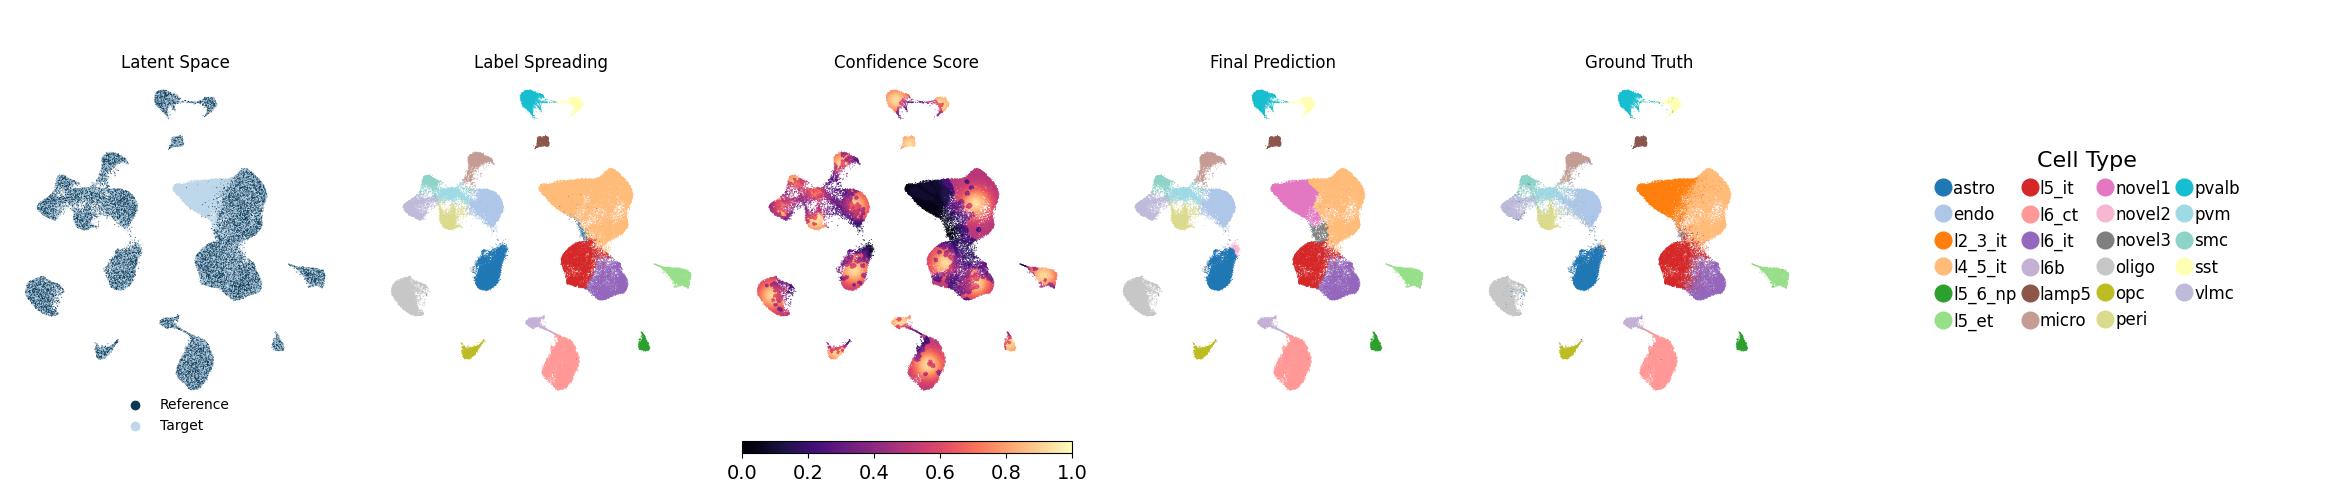

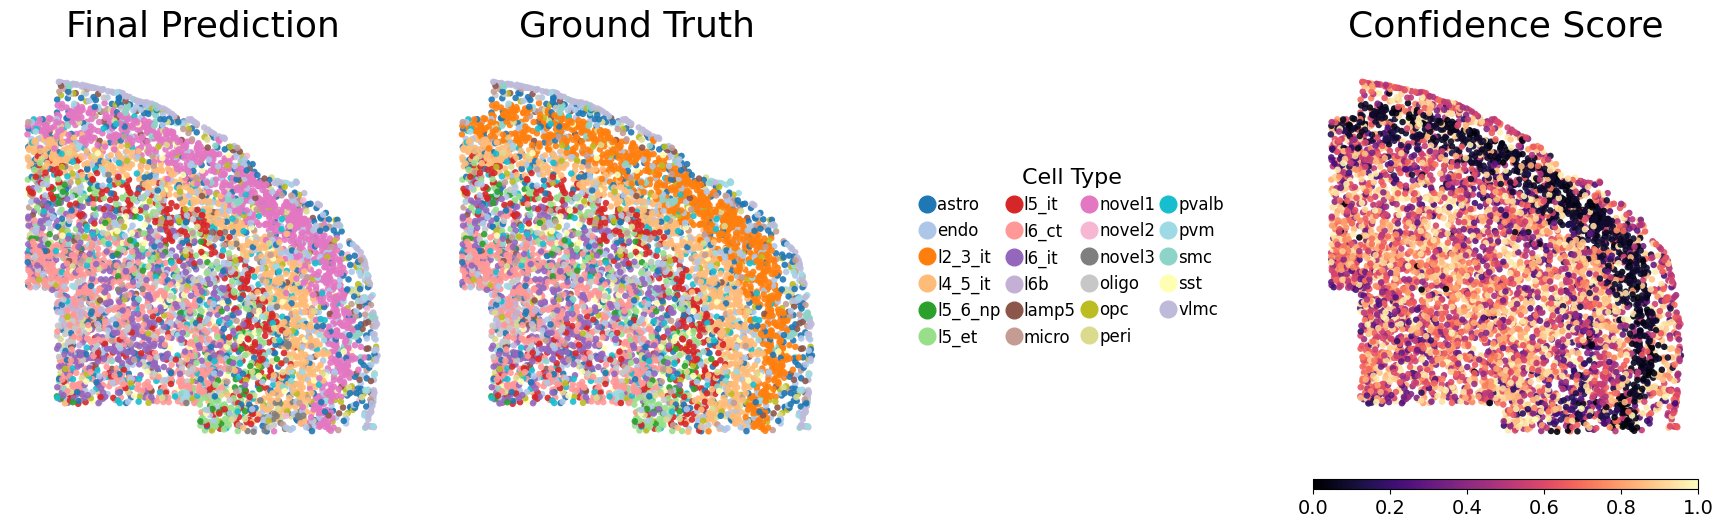

In [5]:
metrics_df = NovAST_evaluation(args)